# LangGraph ReAct Agent 示範

ReAct 代表 **Reasoning + Acting**。Agent 會先判斷需要哪些資訊，選擇工具執行，再根據工具結果繼續判斷，直到能產生最終答案。

本例的任務是：取得一段隨機的《Game of Thrones》名言，再搜尋說出該名言之角色的演員。

## 1. Import libraries

In [1]:
import json
import os
import time
from typing import Dict

import requests
from IPython.display import Image, display
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode
from tavily import TavilyClient

## 2. 建立工具（Action）

第一個工具呼叫公開 API 取得隨機名言，第二個工具使用 Tavily 搜尋網路。請先在系統環境變數設定 `OPENAI_API_KEY` 與 `TAVILY_API_KEY`。

In [2]:
@tool
def random_got_quote() -> Dict:
    """使用瀏覽器形式的 HTTP 請求，取得一段隨機的 Game of Thrones 名言與角色。"""
    url = "https://api.gameofthronesquotes.xyz/v1/random"
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/140.0.0.0 Safari/537.36"
        ),
        "Accept": "application/json, text/plain, */*",
        "Accept-Language": "en-US,en;q=0.9",
        "Referer": "https://api.gameofthronesquotes.xyz/",
        "Connection": "keep-alive",
    }

    max_retries = 4
    backoff = 1

    for attempt in range(1, max_retries + 1):
        try:
            response = requests.get(url, headers=headers, timeout=10)

            if response.status_code == 429:
                print(f"Attempt {attempt}: 429 Too Many Requests")
                if attempt == max_retries:
                    return {
                        "error": "429 Too Many Requests",
                        "status_code": 429,
                        "response_text": response.text[:500],
                    }
                time.sleep(backoff)
                backoff *= 2
                continue

            response.raise_for_status()

            content_type = response.headers.get("Content-Type", "")
            if "application/json" in content_type or "json" in content_type:
                try:
                    return response.json()
                except Exception as error:
                    return {
                        "error": "Invalid JSON in response",
                        "exception": str(error),
                        "status_code": response.status_code,
                        "response_text": response.text[:500],
                    }

            try:
                return response.json()
            except Exception as error:
                return {
                    "error": "Non-JSON response",
                    "exception": str(error),
                    "status_code": response.status_code,
                    "response_text": response.text[:500],
                }

        except requests.RequestException as error:
            print(f"Attempt {attempt}: RequestException: {error}")
            if attempt == max_retries:
                return {"error": "RequestException", "exception": str(error)}
            time.sleep(backoff)
            backoff *= 2

    return {"error": "max_retries_exhausted"}

In [3]:
tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])


@tool
def web_search(question: str) -> Dict:
    """搜尋網路以回答問題。"""
    return tavily_client.search(question)

工具可以單獨測試；以下兩格不是 ReAct 迴圈的必要部分。

In [4]:
quote_result = random_got_quote.invoke({})
print(json.dumps(quote_result, indent=2, ensure_ascii=False))

{
  "sentence": "You're a dragon. Be a dragon.",
  "character": {
    "name": "Olenna Tyrell",
    "slug": "olenna",
    "house": {
      "name": "House Tyrell of Highgarden",
      "slug": "tyrell"
    }
  }
}


In [5]:
web_search.invoke({"question": "Who played Cersei Lannister in Game of Thrones?"})

{'query': 'Who played Cersei Lannister in Game of Thrones?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Lena_Headey',
   'title': 'Lena Headey - Wikipedia',
   'content': 'Lena Kathren Headey (/ˈliːnə ˈhiːdi/ LEE-nə HEE-dee; born 3 October 1973) is a British actress. She gained international recognition and acclaim for her portrayal of Cersei Lannister on the HBO fantasy drama series Game of Thrones (2011–2019), for which she received five Emmy Award nominations and a Golden Globe Award nomination. She was nominated for a Saturn Award for her portrayal of Gorgo, Queen of Sparta, in 300 "300 (film)") (2006). [...] Beginning in April 2011, Headey portrayed queen regent Cersei Lannister on the HBO series Game of Thrones, based on George R. R. Martin\'s A Song of Ice and Fire series of novels. She was cast in the role after her friend and eventual co-star, Peter Dinklage, suggested her casting to producers. Her performa

## 3. 將工具提供給 LLM（Reasoning）

`bind_tools()` 會把工具名稱、說明與參數格式提供給模型。模型可以選擇直接回答，也可以透過 `tool_calls` 要求執行工具。

In [6]:
tools = [random_got_quote, web_search]

llm = ChatOpenAI(
    api_key=os.environ["OPENAI_API_KEY"],
    model=os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    temperature=0.0,
)

llm_with_tools = llm.bind_tools(tools)

## 4. 建立 Agent 與 Router

- `agent`：讓 LLM 根據目前所有訊息進行判斷。
- `router`：若 LLM 產生 `tool_calls`，前往工具節點；否則結束並輸出答案。
- `ToolNode`：執行工具，並將結果轉成 `ToolMessage`（Observation）。

In [7]:
def agent(state: MessagesState):
    ai_message = llm_with_tools.invoke(state["messages"])
    return {"messages": [ai_message]}


def router(state: MessagesState):
    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return END

## 5. 建立 ReAct Graph

最重要的是 `tools → agent` 這條回邊。工具執行完畢後，LLM 會觀察結果並再次判斷；只要仍有 `tool_calls`，循環就會繼續。

In [8]:
workflow = StateGraph(MessagesState)

workflow.add_node("agent", agent)
workflow.add_node("tools", ToolNode(tools))

workflow.add_edge(START, "agent")
workflow.add_conditional_edges(
    source="agent",
    path=router,
    path_map=["tools", END],
)
workflow.add_edge("tools", "agent")

graph = workflow.compile()

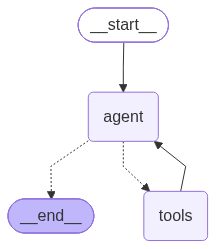

In [9]:
display(Image(graph.get_graph().draw_mermaid_png()))

## 6. 執行 ReAct Agent

我們只描述目標，不指定工具的呼叫順序。Agent 應先取得名言，再根據角色搜尋演員，最後整理答案。

In [10]:
messages = [
    SystemMessage(
        content=(
            "You are a Game of Thrones research agent. "
            "When the user asks for a random quote, first use the quote tool. "
            "Then search the web for the actor or actress who played that character. "
            "Your final answer must include the quote, character, and performer."
        )
    ),
    HumanMessage(content="Give me a random Game of Thrones quote."),
]

result = graph.invoke({"messages": messages})

## 7. 觀察 ReAct 軌跡

以下訊息通常會依序包含：HumanMessage、帶有 `tool_calls` 的 AIMessage、工具回傳的 ToolMessage，以及最終 AIMessage。模型的私有思考不會顯示，但工具選擇與觀察結果可以從訊息中檢查。

In [11]:
for index, message in enumerate(result["messages"], start=1):
    print(f"\n--- Step {index}: {message.__class__.__name__} ---")
    message.pretty_print()


--- Step 1: SystemMessage ---
================================ System Message ================================

You are a Game of Thrones research agent. When the user asks for a random quote, first use the quote tool. Then search the web for the actor or actress who played that character. Your final answer must include the quote, character, and performer.

--- Step 2: HumanMessage ---
================================ Human Message =================================

Give me a random Game of Thrones quote.

--- Step 3: AIMessage ---
================================== Ai Message ==================================
Tool Calls:
  random_got_quote (call_icJXSIw9Px3fw5GbKzhigwwI)
 Call ID: call_icJXSIw9Px3fw5GbKzhigwwI
  Args:

--- Step 4: ToolMessage ---
================================= Tool Message =================================
Name: random_got_quote

{"sentence": "Love is more powerful than reason. We all know that.", "character": {"name": "Tyrion Lannister", "slug": "tyrion", "house

In [12]:
print("Final answer:")
print(result["messages"][-1].content)

Final answer:
Here is a random quote from Game of Thrones:

"Love is more powerful than reason. We all know that." - **Tyrion Lannister**

This character was portrayed by **Peter Dinklage** in the series.


## ReAct 對照

| ReAct 概念 | 本例中的實作 |
|---|---|
| Reason | `agent` 節點中的 LLM 判斷 |
| Action | `AIMessage.tool_calls` 指定工具與參數 |
| Observation | `ToolNode` 執行後產生的 `ToolMessage` |
| Loop | `tools → agent` 回邊 |
| Final Answer | 沒有新的 `tool_calls`，由 router 前往 `END` |

> 本例沒有加入 checkpointer，因為重點是單次 ReAct 任務。若要在多次 `graph.invoke()` 之間延續對話，再加入 `MemorySaver` 與 `thread_id`。